<a href="https://www.kaggle.com/code/atrbyg24/regression-with-an-abalone?scriptVersionId=170307881" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score, cross_val_predict

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [4]:
train = pd.read_csv('/kaggle/input/playground-series-s4e4/train.csv').set_index('id')
test = pd.read_csv('/kaggle/input/playground-series-s4e4/test.csv')

In [5]:
train.head()

,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
id,,,,,,,,,
0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [6]:
train.describe()

,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [7]:
train.nunique()

Sex                  3
Length             157
Diameter           126
Height              90
Whole weight      3175
Whole weight.1    1799
Whole weight.2     979
Shell weight      1129
Rings               28
dtype: int64

array([[<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Diameter'}>,
        <Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Whole weight'}>],
       [<Axes: title={'center': 'Whole weight.1'}>,
        <Axes: title={'center': 'Whole weight.2'}>,
        <Axes: title={'center': 'Shell weight'}>,
        <Axes: title={'center': 'Rings'}>]], dtype=object)

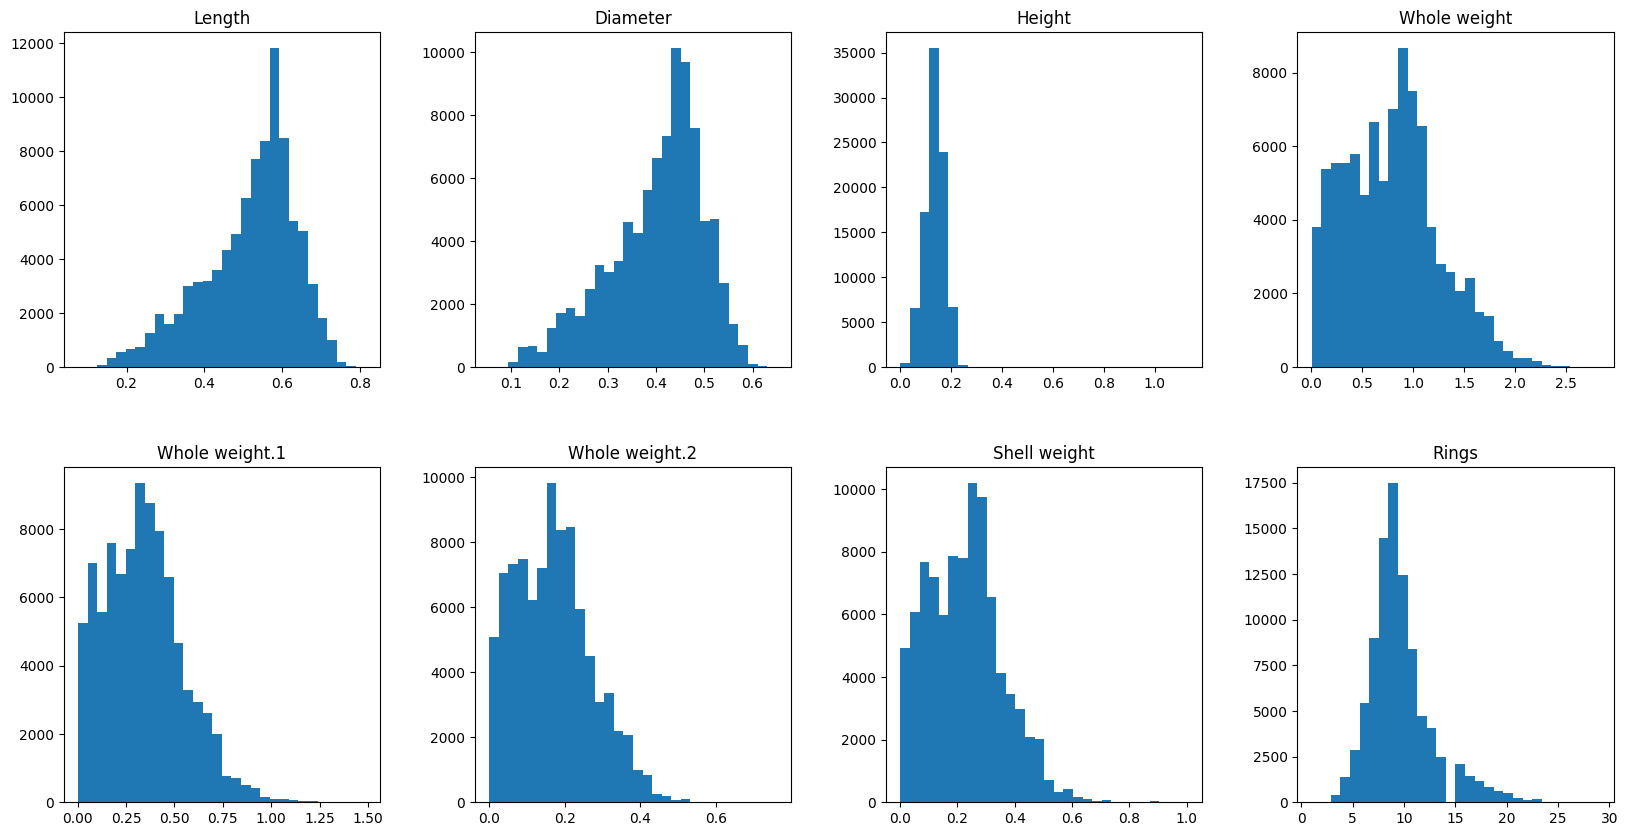

In [8]:
train.hist(figsize=(20,10), grid=False, layout=(2, 4), bins = 30)

In [9]:
def add_features(data):
    # Ratio Features
    data['Weight1 ratio'] = data['Whole weight.1']/data['Whole weight']
    data['Weight2 ratio'] = data['Whole weight.2']/data['Whole weight']
    data['Shell weight ratio'] = data['Shell weight']/data['Whole weight']
    data['Length diameter ratio'] = data['Length']/data['Diameter']

    # Geometric Features
    data['Surface area'] = 2*(data['Length']*data['Diameter']+data['Length']*data['Height']+data['Diameter']*data['Height'])
    data['Shell area'] = data['Length']*data['Diameter']
    data['Volume'] = data['Length']*data['Diameter']*data['Height']

    # Polynomial features
    data['Length squared'] = data['Length']*data['Length']
    data['Diameter squared'] = data['Diameter']*data['Diameter']

    # Logarithmic Features
    data['Log length'] = np.log1p(data['Length'])
    data['Log diameter'] = np.log1p(data['Diameter'])
    data['Log height'] = np.log1p(data['Height'])
    data['Log whole weight'] = np.log1p(data['Whole weight'])
    data['Log whole weight.1'] = np.log1p(data['Whole weight.1'])
    data['Log whole weight.2'] = np.log1p(data['Whole weight.2'])
    data['Log shell weight'] = np.log1p(data['Shell weight'])

    return data

In [10]:
add_features(train)
add_features(test)

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Weight1 ratio,...,Volume,Length squared,Diameter squared,Log length,Log diameter,Log height,Log whole weight,Log whole weight.1,Log whole weight.2,Log shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005,0.499596,...,0.047488,0.416025,0.225625,0.497740,0.388658,0.144100,0.805583,0.481500,0.271934,0.262749
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750,0.486775,...,0.042688,0.336400,0.211600,0.457425,0.378436,0.148420,0.684611,0.391028,0.198441,0.242946
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405,0.419893,...,0.032928,0.313600,0.176400,0.444686,0.350657,0.131028,0.609494,0.301955,0.169321,0.215515
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350,0.403318,...,0.040498,0.324900,0.240100,0.451076,0.398776,0.135405,0.628075,0.301955,0.171008,0.211071
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050,0.439944,...,0.014836,0.172225,0.105625,0.347130,0.281412,0.104360,0.306013,0.146263,0.064851,0.099845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60406,151021,I,0.345,0.260,0.085,0.1775,0.0735,0.0265,0.0500,0.414085,...,0.007625,0.119025,0.067600,0.296394,0.231112,0.081580,0.163394,0.070924,0.026155,0.048790
60407,151022,F,0.525,0.410,0.145,0.8445,0.3885,0.1670,0.2050,0.460036,...,0.031211,0.275625,0.168100,0.421994,0.343590,0.135405,0.612208,0.328224,0.154436,0.186480
60408,151023,I,0.590,0.440,0.155,1.1220,0.3930,0.2000,0.2650,0.350267,...,0.040238,0.348100,0.193600,0.463734,0.364643,0.144100,0.752359,0.331460,0.182322,0.235072
60409,151024,F,0.660,0.525,0.190,1.4935,0.5885,0.3575,0.4350,0.394041,...,0.065835,0.435600,0.275625,0.506818,0.421994,0.173953,0.913687,0.462790,0.305645,0.361165


In [11]:
y_train = np.log1p(train['Rings'])
X_train = train.drop(['Rings'], axis = 1)
X_test = test.drop(['id'], axis = 1)

In [12]:
# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer([
    ('Scale', StandardScaler(), make_column_selector(dtype_include = 'float64')),
    ('One Hot', OneHotEncoder(handle_unknown = 'ignore'), make_column_selector(dtype_include = 'object'))
])

In [23]:
param_dist_xgb = {
    'n_estimators': [100,200,300,400,500],
    'max_depth': [2, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 1.0, 2.0, 3.0, 4.0],
    'objective': ['reg:squarederror'],
    'eval_metric': ['rmse']
}


xgb = XGBRegressor(random_state=17)
xgb_model = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist_xgb, n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=17, n_jobs=-1, verbose=1)


In [21]:
preprocessor.fit(pd.concat([X_train, X_test]))

X_train = pd.DataFrame(preprocessor.transform(X_train))
X_test = pd.DataFrame(preprocessor.transform(X_test))

In [24]:
xgb_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'eval_metric': ['rmse'],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'objective': ['reg:squarederror'],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 1.0, 2.0, 3.0, 4.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=17, scoring='neg_mean_squared_error',
                   verbose=1)

In [25]:
preds = np.expm1(xgb_model.predict(X_test))
submission = pd.DataFrame({'id': test.id, 'Rings': preds})
submission.to_csv('submission.csv', index = False)